In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

In [6]:
df = pd.read_csv('Iris (2).csv')

print(df.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


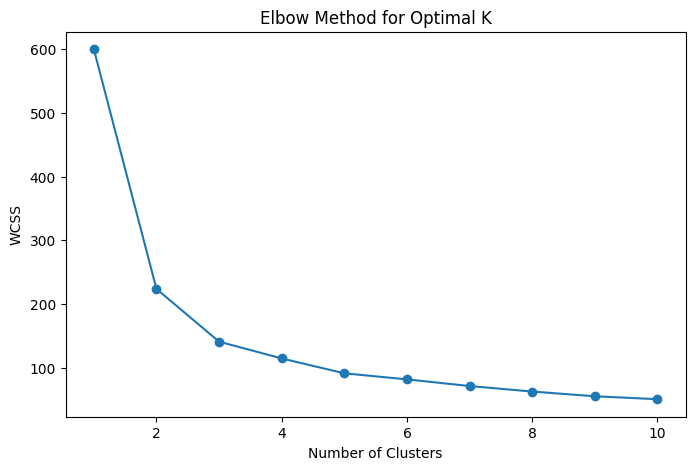


K-Means Cluster Counts:
KMeans_Cluster
0    53
1    50
2    47
Name: count, dtype: int64


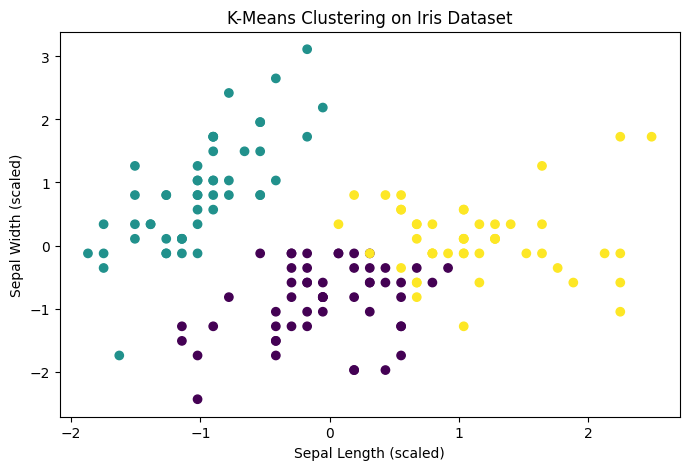

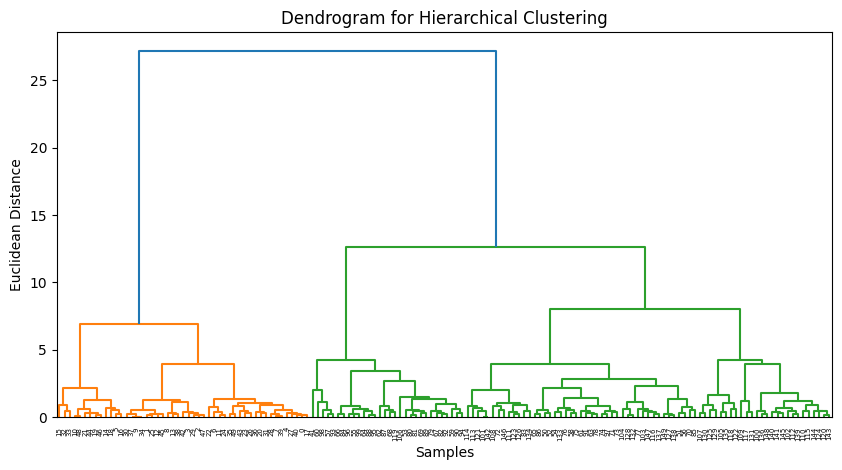


Hierarchical Cluster Counts:
Hierarchical_Cluster
0    71
1    49
2    30
Name: count, dtype: int64


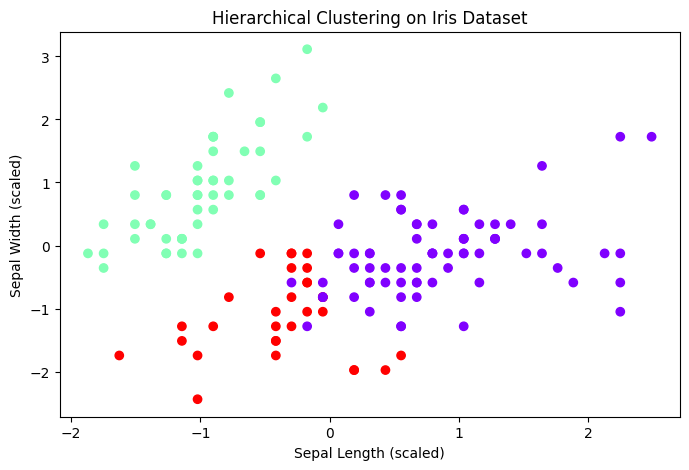


Final Dataset with Cluster Labels:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species  \
0   1            5.1           3.5            1.4           0.2  Iris-setosa   
1   2            4.9           3.0            1.4           0.2  Iris-setosa   
2   3            4.7           3.2            1.3           0.2  Iris-setosa   
3   4            4.6           3.1            1.5           0.2  Iris-setosa   
4   5            5.0           3.6            1.4           0.2  Iris-setosa   
5   6            5.4           3.9            1.7           0.4  Iris-setosa   
6   7            4.6           3.4            1.4           0.3  Iris-setosa   
7   8            5.0           3.4            1.5           0.2  Iris-setosa   
8   9            4.4           2.9            1.4           0.2  Iris-setosa   
9  10            4.9           3.1            1.5           0.1  Iris-setosa   

   KMeans_Cluster  Hierarchical_Cluster  
0               1                     1  

In [7]:
# 3. SELECT FEATURES
# ==============================
X = df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]

# ==============================
# 4. STANDARDIZE THE DATA
# ==============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==============================
# 5. ELBOW METHOD FOR K-MEANS
# ==============================
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

# ==============================
# 6. APPLY K-MEANS CLUSTERING
# ==============================
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

print("\nK-Means Cluster Counts:")
print(df['KMeans_Cluster'].value_counts())

# ==============================
# 7. VISUALIZE K-MEANS CLUSTERS
#    using first two features
# ==============================
plt.figure(figsize=(8, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=df['KMeans_Cluster'], cmap='viridis')
plt.title("K-Means Clustering on Iris Dataset")
plt.xlabel("Sepal Length (scaled)")
plt.ylabel("Sepal Width (scaled)")
plt.show()

# ==============================
# 8. DENDROGRAM FOR HIERARCHICAL CLUSTERING
# ==============================
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(linked)
plt.title("Dendrogram for Hierarchical Clustering")
plt.xlabel("Samples")
plt.ylabel("Euclidean Distance")
plt.show()

# ==============================
# 9. APPLY HIERARCHICAL CLUSTERING
# ==============================
hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
df['Hierarchical_Cluster'] = hc.fit_predict(X_scaled)

print("\nHierarchical Cluster Counts:")
print(df['Hierarchical_Cluster'].value_counts())

# ==============================
# 10. VISUALIZE HIERARCHICAL CLUSTERS
# ==============================
plt.figure(figsize=(8, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=df['Hierarchical_Cluster'], cmap='rainbow')
plt.title("Hierarchical Clustering on Iris Dataset")
plt.xlabel("Sepal Length (scaled)")
plt.ylabel("Sepal Width (scaled)")
plt.show()

# ==============================
# 11. FINAL OUTPUT
# ==============================
print("\nFinal Dataset with Cluster Labels:")
print(df.head(10))